<a href="https://colab.research.google.com/github/NatGN/Practicas-de-seminario-de-mineria-de-datos/blob/main/REGRESI%C3%93N_LINEALEjer1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score #Metricas de evaluación


In [5]:
#Carga y exploración inicial de datos
df = pd.read_csv('PublicidadVentas.csv')
df.head()

,Inversion,Ventas
0,1.2,180
1,1.5,210
2,1.8,250
3,2.0,280
4,2.2,300


In [6]:
#Información Básica del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Inversion  70 non-null     float64
 1   Ventas     70 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.2 KB


In [7]:
#Estadisticas descriptivas para entender la distribucion
df.describe()


,Inversion,Ventas
count,70.000000,70.000000
mean,9.880000,908.000000
std,5.093605,410.071044
min,1.200000,180.000000
25%,5.575000,565.000000
50%,9.900000,910.000000
75%,14.150000,1255.000000
max,18.500000,1600.000000


In [8]:
#Preparación de los datos
#Seleccionamos las variables:
#X: independiente (predictora) - inversion
#y: dependiente (a predecir) - ventas

#Extraemos los valores como arrays de numpy para el modelo
X = df[['Inversion']].values  # Variable independiente
y = df['Ventas'].values       # Variable dependiente

In [9]:
# 2. Ajustar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X, y)


LinearRegression()

In [10]:
# Parámetros del modelo
pendiente = modelo.coef_[0]
interseccion = modelo.intercept_

In [11]:
# 3. Evaluar la calidad del modelo
y_pred = modelo.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

In [12]:
print(f"--- Evaluación del Modelo ---")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")
print(f"Ecuación: Ventas = {pendiente:.2f} * Inversion + {interseccion:.2f}")

--- Evaluación del Modelo ---
MSE: 38.76
R²: 1.00
Ecuación: Ventas = 80.50 * Inversion + 112.68


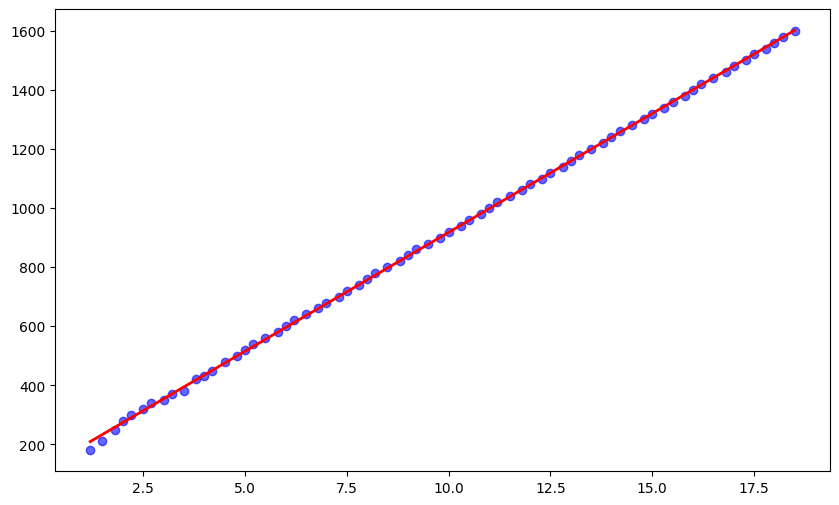

In [13]:
# 4. Visualización profesional
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, label='Datos Históricos')
plt.plot(X, y_pred, color='red', linewidth=2, label='Línea de Regresión')

In [ ]:
# Mostrar la ecuación y métricas en el gráfico
texto_info = (f'$Ventas = {pendiente:.2f} \\cdot Inversion + {interseccion:.2f}$\n'
              f'$R^2 = {r2:.2f}$')

plt.text(X.min(), y.max() * 0.9, texto_info, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

plt.xlabel('Inversión en Publicidad Digital (Miles de USD)')
plt.ylabel('Unidades Vendidas')
plt.title('Impacto de la Publicidad en las Ventas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()